In [58]:
import numpy as np  
import random  
import matplotlib.pyplot as plt  
from PIL import Image  
import os  
import math

In [59]:
# Quadtree:
class Quadtree:
    def __init__(self, x_min, x_max, y_min, y_max, max_points=4, depth=0):
        self.x_min, self.x_max = x_min, x_max  # x ašies riba
        self.y_min, self.y_max = y_min, y_max  # y ašies riba
        self.max_points = max_points  # Maksimalus dalelių skaičius viename node
        self.depth = depth  # Nusako quadtree gylį (nusako nodų skaičių)
        self.points = []  # taškai viename node
        self.children = []  # child nodai

    def insert(self, point, index):
        # Patikrina ar taškas tam tikro nodo ribose
        if not (self.x_min < point[0] < self.x_max and self.y_min < point[1] < self.y_max):
            return False  
        
        # Jei yra vietos ir nėra child nodo jis sukūria tašką laisvoje vietoje
        if len(self.points) < self.max_points and not self.children:
            self.points.append((point, index))  
            return True
        
        #Jei nėra child nodo jis padalija nodą į 4 child nodus
        if not self.children:
            self.subdivide()
        
        # įkelia tašką į vieną iš child nodų
        for child in self.children:
            if child.insert(point, index):
                return True
        return False
    
    def subdivide(self):
        # Padalina nodą į 4 child nodus ir suranda jų vidurio tašką
        mid_x = (self.x_min + self.x_max) / 2
        mid_y = (self.y_min + self.y_max) / 2
        self.children = [
            Quadtree(self.x_min, mid_x, self.y_min, mid_y, self.max_points, self.depth + 1),
            Quadtree(mid_x, self.x_max, self.y_min, mid_y, self.max_points, self.depth + 1),
            Quadtree(self.x_min, mid_x, mid_y, self.y_max, self.max_points, self.depth + 1),
            Quadtree(mid_x, self.x_max, mid_y, self.y_max, self.max_points, self.depth + 1),
        ]  # Sukuria 4 child nodus
        for point, index in self.points:  # Perkelia taškus iš parent nodo į child nodą
            for child in self.children:
                if child.insert(point, index):
                    break
        self.points = []  # Ištrina taškus iš parent nodo.
    
    def query_range(self, x, y, radius): #query_range ieško tam tikrų taškų Quadtree erdvėje
        results = []  
        # Patikrina ar tai įeina į Quadtree ribas 
        if x + radius < self.x_min or x - radius > self.x_max or y + radius < self.y_min or y - radius > self.y_max:
            return results  
        
        # Patikrina taškus mazge ar jie įeina į spindulį
        for point, index in self.points:
            if np.linalg.norm(np.array(point) - np.array([x, y])) <= radius:
                results.append(index)
        
       
        if self.children:
            for child in self.children:
                results.extend(child.query_range(x, y, radius))  # Čia kaip suprantu Quadtree tikrina kurie "children" turi tam tikram spinduly dalelių kurie ne tuos atmeta.
        return results

In [60]:
# Klasė kuri sukūria daleles ir parenka jiems lokalizuotas būsens, energiją ir poziciją.
class LocalizedStates:
    def __init__(self, N, box_size):
        self.N = N  # Lokalizuotų būsenų skaičius (dalelių skaičius)
        self.box_size = box_size  # Dydis tos erdvės kur yra dalelės
        
        # Parenka tiek pozicijų kiek yra dalelių
        self.positions = np.random.rand(N, 2) * box_size  # Parenka pozicijas
        # Sukūria energijas nuo -0.1 iki 0
        self.energies = np.random.uniform(-0.1, 0.0, size=N)
        
        # Sukūria Quadtree pozicijas
        self.tree = Quadtree(0, box_size, 0, box_size)
        for i in range(N):
            self.tree.insert(self.positions[i], i)  # Įrašo kiekvieną dalelę į Quadtree
    
    def update_plot(self, ax, colorbar=False):  #plotinimas
        ax.clear()  # Clear the axes
        scatter = ax.scatter(self.positions[:, 0], self.positions[:, 1], c=self.energies, cmap='coolwarm', vmin=-0.1, vmax=0.0)  # Plotina pozicijas ir energijas
        ax.set_xlabel("X Position (nm)")  
        ax.set_ylabel("Y Position (nm)")  
        ax.set_title("Excitons in AlGaAs")  
        
        if colorbar:   #Colorbaras
            cbar = ax.figure.colorbar(scatter, ax=ax, label="Energy (eV)")
        
        return scatter

In [61]:
def miller_abrahams_rate(E_i, E_j, r_ij, a, nu_0, kT): #Miller abramso formulė kuri nusako galimybę(šansą) dalalei peršokti
    if E_j > E_i:
        return nu_0 * np.exp(-2 * r_ij / a) * np.exp(-(E_j - E_i) / kT)  
    else:
        return nu_0 * np.exp(-2 * r_ij / a)  

In [62]:
class Exciton:
    def __init__(self, pos, energy):
        self.pos = pos.copy()
        self.energy = energy
        self.alive = True
        self.traj = [self.pos.copy()]
        self.emitted_energy = None

In [ ]:
# KMC klasė
class KMC_Simulator:
    def __init__(self, states, a=5.0, nu_0=1e13, kT=0.025):
        self.states = states  # Lokalizacijos būsenos
        self.a = a  # Lokalizacijos ilgis (nm)
        self.nu_0 = nu_0  # Dažnis (Hz)
        self.kT = kT  # Energija (eV)
        self.time = 0  # Simuliacijos laikas
    
    def run_step(self, exciton, cutoff=10.0):
        if not exciton.alive: #jei eksitonas rekombinuoja tada jis "negyvas"
            return

        # suranda tam tikram spindulyje eksitono pozicija
        nbrs = self.states.tree.query_range(exciton.pos[0],
                                            exciton.pos[1],
                                            cutoff)
        
        rates = []


        for j in nbrs:

            r_ij = np.linalg.norm(self.states.positions[j] - exciton.pos) # suranda r_ij
            if r_ij < 1e-6: # jei atstumas per mažas tada praleidžia nes čia ta pati vieta
                continue
            rate = miller_abrahams_rate( # Miller-Abrahams šokinėjimo dažnio skaičiavimas
                exciton.energy, # Pradinė energija
                self.states.energies[j], # kaimyno energija
                r_ij, # atstmas
                self.a, # lokalizacijos ilgis
                self.nu_0, # dažnis
                self.kT # temperatūros energija
            )
            if rate > 0: # parenka teigiamus dažnius
                rates.append((j, rate))

        # Rekombinacijos dažnis kai gyvavimo trukmė 1ns
        rec_rate = 1.0 / 1e-9
        total_rate = rec_rate + sum(r for _, r in rates) # Bendras dažnis 
        if total_rate == 0: # Jei neįvyksta jokie įvykiai tada praleidžia
            return

        r_sel = random.random() * total_rate # atsitiktinis įvykis

        
        if r_sel < rec_rate: 
            exciton.alive = False # Čia kodas kuris pažymi ar eksitonas rekombinavosi
            exciton.emitted_energy = exciton.energy
            return

        cum = rec_rate # Akumuliuotas dažnis
        for j, rate in rates: 
            cum += rate
            if r_sel < cum:
                # Eksitono peršokimas
                exciton.pos = self.states.positions[j].copy()
                exciton.energy = self.states.energies[j]
                exciton.traj.append(exciton.pos.copy())
                break

        
        dt = -math.log(random.random()) / total_rate #Apskaičiuoja laiko žingsnį
        self.time += dt #Simuliacijos laikas
        print("Delta t:", dt)
        print("Total time:", self.time)
    
    def run_simulation(self,
                    N_excitons=5, #Eksitonų skaičius
                    steps=100, #Žingsnių skaičius
                    save_path="exciton_simulation.gif"):
        
        excitons = []
        for _ in range(N_excitons):
            idx = random.randrange(self.states.N) #Eksitonai atsiranda random vietose
            pos0 = self.states.positions[idx]
            e0   = self.states.energies[idx]
            excitons.append(Exciton(pos0, e0))

        fig, ax = plt.subplots(figsize=(6,6)) #Plotinimas
        frames = []

        self.states.update_plot(ax, colorbar=True)
        scatter = ax.scatter([ex.pos[0] for ex in excitons],
                            [ex.pos[1] for ex in excitons],
                            c='black', s=5, label='excitons')
        ax.legend()
        plt.savefig("frame_0.png")
        frames.append("frame_0.png")


        for step in range(1, steps+1):
            for ex in excitons:
                if ex.alive:
                    self.run_step(ex)

 
            self.states.update_plot(ax, colorbar=False)
            scatter = ax.scatter([ex.pos[0] for ex in excitons if ex.alive],
                                [ex.pos[1] for ex in excitons if ex.alive],
                                c='black', s=5)
            frame = f"frame_{step}.png"
            plt.savefig(frame)
            frames.append(frame)


        self.create_gif(frames, save_path)

        for f in frames:
            os.remove(f)


        emitted = [ex.emitted_energy for ex in excitons if ex.emitted_energy is not None]  #suranda eksitonus kurie rekombinavo ir ju energija
        n_emit = len(emitted) 
        print(f"Number recombined: {n_emit} / {N_excitons}")
        if n_emit > 0:
            mean_E = np.mean(emitted)
            print(f"Mean emission energy: {mean_E:.3f} eV")
        else:
            print("No recombinations occurred; mean emission undefined.")
        print("Num recombined:", len(emitted))
        print("Mean emission E:", np.mean(emitted))

    def create_gif(self, frames, save_path):
 
        from PIL import Image
        images = [Image.open(f) for f in frames]
        images[0].save(
            save_path,
            save_all=True,
            append_images=images[1:],
            duration=100,
            loop=0
        )
        print(f"GIF saved as {save_path}")


Delta t: 7.208255265373436e-13
Total time: 7.208255265373436e-13
Delta t: 4.259715168479778e-14
Total time: 7.634226782221413e-13
Delta t: 1.2532523600344873e-12
Total time: 2.0166750382566285e-12
Delta t: 9.86472186435446e-14
Total time: 2.115322256900173e-12
Delta t: 7.359246386249725e-13
Total time: 2.8512468955251454e-12
Delta t: 4.06344212877775e-14
Total time: 2.891881316812923e-12
Delta t: 5.16410883207381e-13
Total time: 3.4082922000203038e-12
Delta t: 6.488467272260633e-13
Total time: 4.057138927246367e-12
GIF saved as exciton_simulation.gif
Number recombined: 5 / 5
Mean emission energy: -0.079 eV
Num recombined: 5
Mean emission E: -0.07948127284679112


True

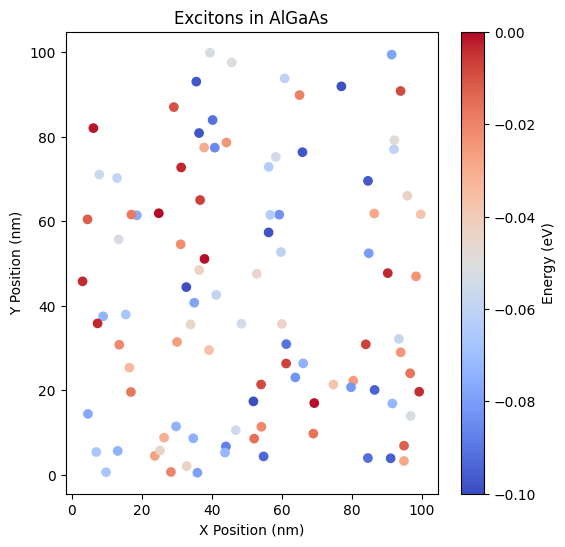

In [ ]:
states = LocalizedStates(N=100, box_size=100) #Kiek dalelių ir kiek lokalizuotų būsenų skaičius (100x100)
sim = KMC_Simulator(states, a=5, nu_0=1e13, kT=0.025) #KMC simulatorius simuliuoja jų šokinėjimą pagal nu, kT ir a parametrus
sim.run_simulation(steps=100, save_path="exciton_simulation.gif") #sukuria 100 framu iš kurių padaro simulacijos gifą

import webbrowser
webbrowser.open('exciton_simulation.gif')